In [ ]:
!pip install -q transformers[torch] datasets evaluate rouge_score gradio accelerate sentencepiece
print("Dependencies installed.")

Dependencies installed.


In [ ]:
import torch
import evaluate
import pandas as pd
import numpy as np
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    pipeline
)
import gradio as gr

MODEL_Base = "t5-small"
MODEL_Compare_1 = "facebook/bart-large-cnn"
MODEL_Compare_2 = "google/pegasus-xsum"
DATASET_NAME = "samsum"

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running on: {device}")

Running on: cuda


In [ ]:
DATASET_NAME = "knkarthick/samsum"

dataset = load_dataset(DATASET_NAME)
tokenizer = AutoTokenizer.from_pretrained(MODEL_Base)

def preprocess_function(examples):
    inputs = ["summarize: " + doc for doc in examples["dialogue"]]

    model_inputs = tokenizer(inputs, max_length=1024, truncation=True)
    labels = tokenizer(text_target=examples["summary"], max_length=128, truncation=True)

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

tokenized_datasets = dataset.map(preprocess_function, batched=True)
print("Data preprocessing complete.")

Map:   0%|          | 0/818 [00:00<?, ? examples/s]

Data preprocessing complete.


In [30]:
import gc
import torch
import numpy as np
import evaluate
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    DataCollatorForSeq2Seq
)

rouge = evaluate.load("rouge")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    if isinstance(predictions, tuple):
        predictions = predictions[0]
    predictions = np.array(predictions)
    labels = np.array(labels)
    pad_token_id = 0
    predictions = np.where(predictions < 0, pad_token_id, predictions)
    labels = np.where(labels < 0, pad_token_id, labels)
    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
    result = rouge.compute(predictions=decoded_preds, references=decoded_labels, use_stemmer=True)
    return {k: round(v * 100, 4) for k, v in result.items()}

models_to_train = [
    "t5-small",
    "facebook/bart-base",
    "sshleifer/distilbart-cnn-6-6"
]

saved_model_paths = {}
device = "cuda" if torch.cuda.is_available() else "cpu"

for model_name in models_to_train:
    print(f"Processing: {model_name}")

    # Clean Memory
    torch.cuda.empty_cache()
    gc.collect()

    # Load
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

    # Dynamic Preprocessing
    prefix = "summarize: " if "t5" in model_name else ""

    def preprocess_function_dynamic(examples):
        inputs = [prefix + doc for doc in examples["dialogue"]]
        model_inputs = tokenizer(inputs, max_length=1024, truncation=True)
        labels = tokenizer(text_target=examples["summary"], max_length=128, truncation=True)
        model_inputs["labels"] = labels["input_ids"]
        return model_inputs

    print(f"Tokenizing data for {model_name}...")
    tokenized_data = dataset.map(preprocess_function_dynamic, batched=True)

    # Training Arguments
    output_dir = f"./finetuned_{model_name.replace('/', '_')}"

    training_args = Seq2SeqTrainingArguments(
        output_dir=output_dir,
        report_to="none",
        eval_strategy="steps",
        eval_steps=100,
        learning_rate=2e-5,
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        weight_decay=0.01,
        save_total_limit=1,
        num_train_epochs=1,
        predict_with_generate=True,
        fp16=(device=="cuda"),
        logging_steps=50,
    )

    # Trainer
    trainer = Seq2SeqTrainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_data["train"].select(range(2000)),
        eval_dataset=tokenized_data["test"].select(range(200)),
        tokenizer=tokenizer,
        data_collator=DataCollatorForSeq2Seq(tokenizer, model=model),
        compute_metrics=compute_metrics,
    )

    # Train
    print(f"Training {model_name}...")
    trainer.train()

    # Save
    save_path = f"./saved_{model_name.replace('/', '_')}"
    trainer.save_model(save_path)
    tokenizer.save_pretrained(save_path)
    saved_model_paths[model_name] = save_path

    print(f"Finished {model_name}. Saved to {save_path}")

    # Cleanup
    del model
    del trainer
    del tokenizer
    torch.cuda.empty_cache()

print("\n\nAll models trained successfully!")
print("Saved Paths:", saved_model_paths)

Processing: t5-small
Tokenizing data for t5-small...


Map:   0%|          | 0/818 [00:00<?, ? examples/s]

/tmp/ipython-input-2676213616.py:82: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


Training t5-small...


Step,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum
100,2.559500,2.191006,30.761200,8.811000,25.197600,25.189400
200,2.349600,2.105377,33.075500,11.178100,27.315200,27.322500
300,2.303200,2.066777,34.257200,11.602600,28.144900,28.123600
400,2.289000,2.050530,35.191300,12.696800,28.928200,28.962200
500,2.267500,2.045251,35.217100,12.685000,28.952600,28.976100


...

Training sshleifer/distilbart-cnn-6-6...


Step,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum
100,2.059100,1.944582,35.878900,15.840900,26.103100,26.127300
200,1.967400,1.879157,35.854500,16.488400,26.839100,26.866300
300,1.869200,1.832103,37.206900,16.999500,28.077900,28.095300
400,1.849900,1.801613,36.586600,16.381500,27.323600,27.362600
500,1.826700,1.786423,37.801000,17.074000,28.344500,28.439100


/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:3918: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 142, 'min_length': 56, 'early_stopping': True, 'num_beams': 4, 'length_penalty': 2.0, 'no_repeat_ngram_size': 3, 'forced_bos_token_id': 0}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(


Step,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum
100,2.059100,1.944582,35.878900,15.840900,26.103100,26.127300
200,1.967400,1.879157,35.854500,16.488400,26.839100,26.866300
300,1.869200,1.832103,37.206900,16.999500,28.077900,28.095300
400,1.849900,1.801613,36.586600,16.381500,27.323600,27.362600
500,1.826700,1.786423,37.801000,17.074000,28.344500,28.439100


Finished sshleifer/distilbart-cnn-6-6. Saved to ./saved_sshleifer_distilbart-cnn-6-6


All models trained successfully!
Saved Paths: {'t5-small': './saved_t5-small', 'facebook/bart-base': './saved_facebook_bart-base', 'sshleifer/distilbart-cnn-6-6': './saved_sshleifer_distilbart-cnn-6-6'}


In [31]:
from transformers import pipeline
pipelines = {}

for original_name, saved_path in saved_model_paths.items():
    print(f"Loading {original_name} from {saved_path}...")
    pipelines[original_name] = pipeline("summarization", model=saved_path, device=0 if device=="cuda" else -1)

print("Pipelines ready.")

Loading t5-small from ./saved_t5-small...


Device set to use cuda:0


Loading facebook/bart-base from ./saved_facebook_bart-base...


Device set to use cuda:0


Loading sshleifer/distilbart-cnn-6-6 from ./saved_sshleifer_distilbart-cnn-6-6...


/usr/local/lib/python3.12/dist-packages/transformers/models/bart/configuration_bart.py:177: UserWarning: Please make sure the config includes `forced_bos_token_id=0` in future versions. The config can simply be saved and uploaded again to be fixed.
  warnings.warn(
Device set to use cuda:0


Pipelines ready.


In [38]:
# Cell 10+11: Multi-Metric Comparison (R1, R2, RL)
import gc
import torch
import pandas as pd
import matplotlib.pyplot as plt
import evaluate
from transformers import pipeline

metric = evaluate.load("rouge")
test_subset = dataset["test"].select(range(100))
device = 0 if torch.cuda.is_available() else -1

comparison_targets = [
    {"name": "t5-small", "path": "./saved_t5-small", "prefix": "summarize: "},
    {"name": "facebook/bart-base", "path": "./saved_facebook_bart-base", "prefix": ""},
    {"name": "sshleifer/distilbart-cnn-6-6", "path": "./saved_sshleifer_distilbart-cnn-6-6", "prefix": ""}
]

records_multi = []
for target in comparison_targets:
    model_name = target["name"]
    save_path = target["path"]
    prefix = target["prefix"]
    print(f"Processing {model_name}")
    pipe = pipeline("summarization", model=model_name, device=device)
    preds = [pipe(prefix + t, max_length=128, truncation=True)[0]['summary_text'] for t in test_subset["dialogue"]]
    scores = metric.compute(predictions=preds, references=test_subset["summary"], use_stemmer=True)

    records_multi.append({
        "Model": model_name,
        "State": "Base",
        "ROUGE-1": scores["rouge1"] * 100,
        "ROUGE-2": scores["rouge2"] * 100,
        "ROUGE-L": scores["rougeL"] * 100
    })
    del pipe
    pipe = pipeline("summarization", model=save_path, device=device)
    preds = [pipe(prefix + t, max_length=128, truncation=True)[0]['summary_text'] for t in test_subset["dialogue"]]
    scores = metric.compute(predictions=preds, references=test_subset["summary"], use_stemmer=True)

    records_multi.append({
        "Model": model_name,
        "State": "Fine-Tuned",
        "ROUGE-1": scores["rouge1"] * 100,
        "ROUGE-2": scores["rouge2"] * 100,
        "ROUGE-L": scores["rougeL"] * 100
    })
    del pipe
    gc.collect()
    torch.cuda.empty_cache()

Processing t5-small


Device set to use cuda:0
Both `max_new_tokens` (=256) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_

Processing facebook/bart-base


Device set to use cuda:0
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
Both `max_new_tokens` (=256) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=128) seem to have been set. `max_new_

Processing sshleifer/distilbart-cnn-6-6


Device set to use cuda:0
Your max_length is set to 128, but your input_length is only 126. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=63)
Your max_length is set to 128, but your input_length is only 117. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=58)
Your max_length is set to 128, but your input_length is only 102. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=51)
Your max_length is set to 128, but your input_length is only 36. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarize

Generating 3 Separate Graphs


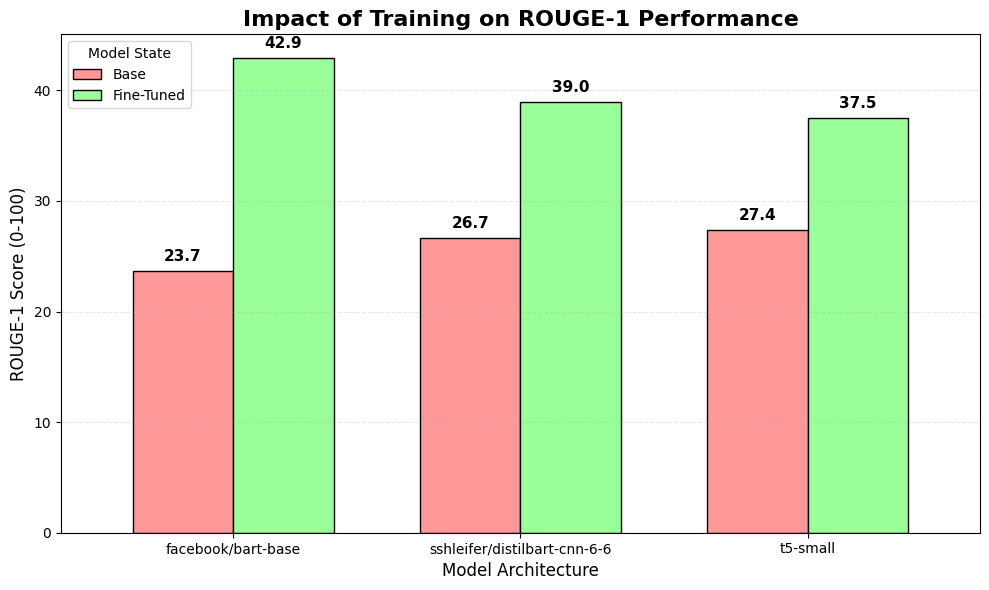

--------------------------------------------------


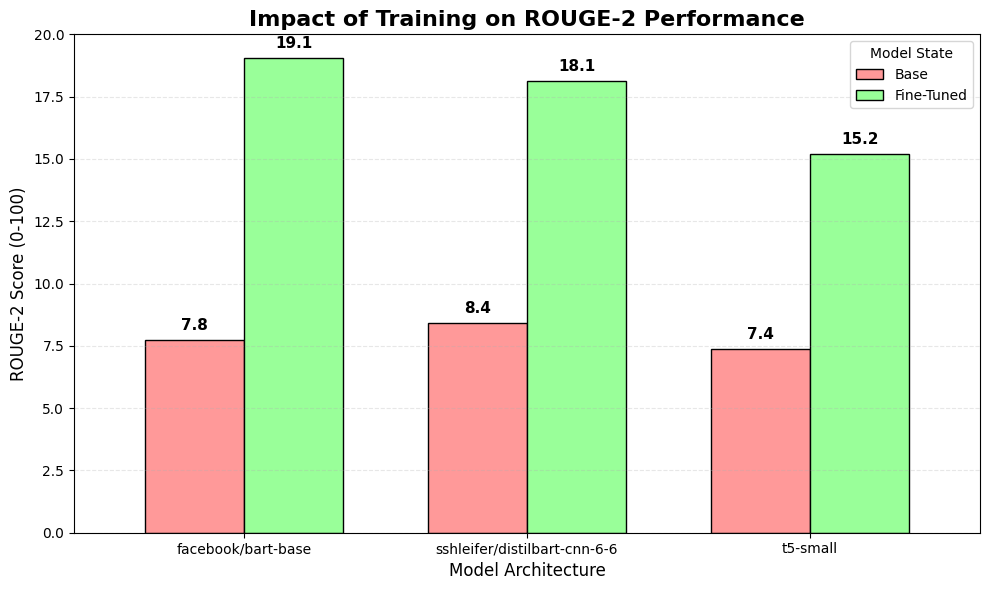

--------------------------------------------------


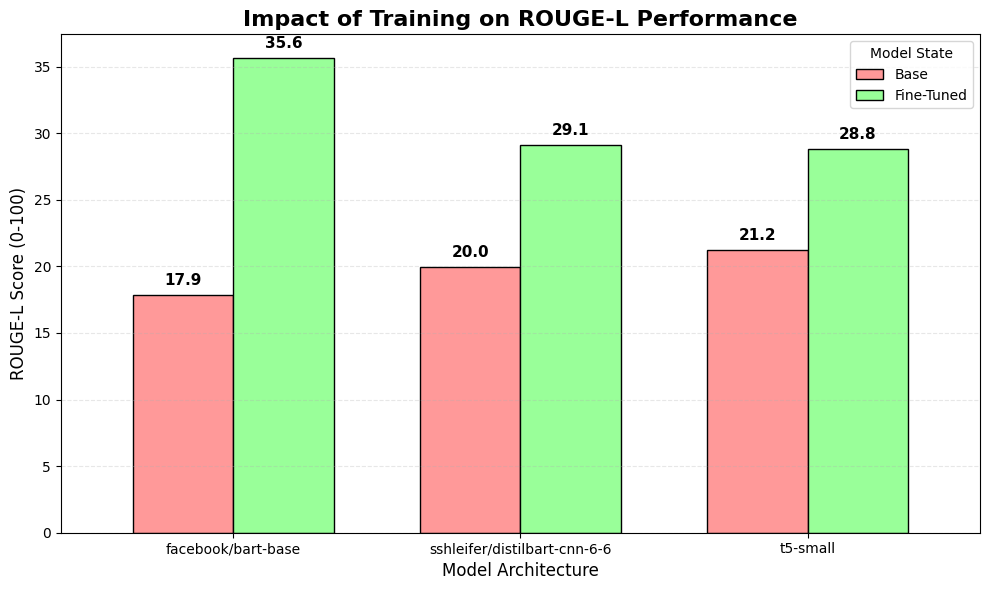

--------------------------------------------------


In [40]:
import matplotlib.pyplot as plt

metrics = ["ROUGE-1", "ROUGE-2", "ROUGE-L"]
colors = ['#ff9999', '#99ff99']

print(f"Generating {len(metrics)} Separate Graphs")

for m in metrics:
    pivot = df_multi.pivot(index="Model", columns="State", values=m)
    fig, ax = plt.subplots(figsize=(10, 6))

    pivot.plot(kind='bar', ax=ax, color=colors, edgecolor='black', width=0.7)

    ax.set_title(f"Impact of Training on {m} Performance", fontsize=16, fontweight='bold')
    ax.set_ylabel(f"{m} Score (0-100)", fontsize=12)
    ax.set_xlabel("Model Architecture", fontsize=12)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    plt.xticks(rotation=0)
    plt.legend(title="Model State", fontsize=10)

    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f"{p.get_height():.1f}",
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom',
                        fontsize=11, fontweight='bold',
                        xytext=(0, 5), textcoords='offset points')

    plt.tight_layout()
    plt.show()
    print("-" * 50)

In [41]:
import gradio as gr
from transformers import pipeline
if 'pipelines' not in globals():
    pipelines = {}
    print("Loading models for UI...")
    for name, path in saved_model_paths.items():
        pipelines[name] = pipeline("summarization", model=path, device=0 if torch.cuda.is_available() else -1)

def generate_comparison(dialogue):
    results = []
    for model_name in saved_model_paths.keys():
        pipe = pipelines[model_name]
        input_text = ("summarize: " + dialogue) if "t5" in model_name else dialogue
        output = pipe(input_text, max_length=100, min_length=10, truncation=True)
        results.append(output[0]['summary_text'])

    return tuple(results)

model_names_list = list(saved_model_paths.keys())
example_dialogue = """
Doctor: Hi, how are you feeling today?
Patient: I have a terrible headache and a sore throat.
Doctor: How long have you had these symptoms?
Patient: About three days now.
Doctor: Okay, let me check your temperature. It seems you have a slight fever.
Patient: Do I need antibiotics?
Doctor: Not yet. I'll prescribe some rest and fluids first. Come back if it gets worse.
"""

iface = gr.Interface(
    fn=generate_comparison,
    inputs=gr.Textbox(lines=10, placeholder="Paste a conversation here...", label="Input Dialogue", value=example_dialogue),
    outputs=[
        gr.Textbox(label=f"Model 1: {model_names_list[0]} (Fine-Tuned)"),
        gr.Textbox(label=f"Model 2: {model_names_list[1]} (Fine-Tuned)"),
        gr.Textbox(label=f"Model 3: {model_names_list[2]} (Fine-Tuned)", max_lines=10)
    ],
    title="AI Summarization Arena: Multi-Model Comparison",
    description="Compare how 3 different fine-tuned architectures summarize the same conversation.",
    theme="default"
)

iface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f83c6555d116ff49ae.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
